data.txt created successfully!
Vocab size: 24
Epoch 1/10 | Train Loss: 0.0868 | Val Loss: 0.0097
Epoch 2/10 | Train Loss: 0.0080 | Val Loss: 0.0094
Epoch 3/10 | Train Loss: 0.0072 | Val Loss: 0.0083
Epoch 4/10 | Train Loss: 0.0072 | Val Loss: 0.0079
Epoch 5/10 | Train Loss: 0.0069 | Val Loss: 0.0077
Epoch 6/10 | Train Loss: 0.0075 | Val Loss: 0.0079
Epoch 7/10 | Train Loss: 0.0076 | Val Loss: 0.0081
Epoch 8/10 | Train Loss: 0.0069 | Val Loss: 0.0076
Epoch 9/10 | Train Loss: 0.0070 | Val Loss: 0.0079
Epoch 10/10 | Train Loss: 0.0067 | Val Loss: 0.0076


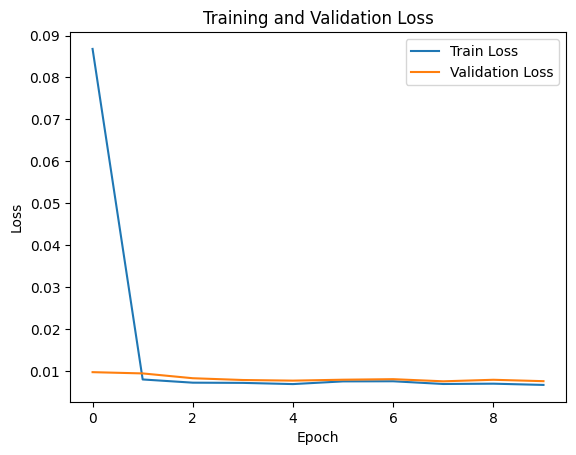


--- Temperature 0.7 ---
he is repeated multiple times to increase size.

hello world. this is a sample dataset for training a character level rnn.
we are learning deep learning models using pytorch.
this dataset is repeated multiple times to increase size.

hello world. this is a sample dataset for training a character level

--- Temperature 1.0 ---
he is repeated multiple times to increase size.

hello world. this is a sample dataset for training a character level rnn.
we are learning deep learning models using pytorch.
this dataset is repeated multiple times to increase size.

hello world. this is a sample dataset for training a character level

--- Temperature 1.2 ---
he learning deep learning models using pytorch.
this dataset is repeated multiple times to increase size.

hello world. this is a sample dataset for size.

hello world. this is a sample dataset for training a character level rnn.
we are learning deep learning models using pytorch.
this dataset is repe


In [22]:
# =========================================
# Q1)Character-Level RNN
# =========================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1. LOAD DATA
# -------------------------------
# Create a dataset file automatically
text = """
hello world. this is a sample dataset for training a character level rnn.
we are learning deep learning models using pytorch.
this dataset is repeated multiple times to increase size.
""" * 200   # repeat to make it bigger (~100KB)

with open("data.txt", "w") as f:
    f.write(text)

print("data.txt created successfully!")

# -------------------------------
# 2. CHAR MAPPING
# -------------------------------
chars = sorted(list(set(text)))
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}
vocab_size = len(chars)

print("Vocab size:", vocab_size)

# Encode
encoded = torch.tensor([char2idx[c] for c in text], dtype=torch.long)

# -------------------------------
# 3. TRAIN / VALIDATION SPLIT
# -------------------------------
split = int(0.9 * len(encoded))
train_data = encoded[:split]
val_data = encoded[split:]

# -------------------------------
# 4. HYPERPARAMETERS
# -------------------------------
seq_len = 50
batch_size = 32
hidden_size = 128
embed_size = 64
epochs = 10
lr = 0.003

# -------------------------------
# 5. BATCH FUNCTION
# -------------------------------
def get_batches(data, seq_len, batch_size):
    total_len = data.size(0)
    num_batches = total_len // (batch_size * seq_len)

    data = data[:num_batches * batch_size * seq_len]
    data = data.view(batch_size, -1)

    for i in range(0, data.size(1) - seq_len):
        x = data[:, i:i+seq_len]
        y = data[:, i+1:i+seq_len+1]
        yield x, y

# -------------------------------
# 6. MODEL
# -------------------------------
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        x = self.embed(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, hidden_size)

model = CharRNN(vocab_size, embed_size, hidden_size)

# -------------------------------
# 7. TRAIN SETUP
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_losses = []
val_losses = []

# -------------------------------
# 8. TRAINING LOOP
# -------------------------------
for epoch in range(epochs):

    # ---- TRAIN ----
    model.train()
    hidden = model.init_hidden(batch_size)

    train_loss = 0
    train_batches = 0

    for x, y in get_batches(train_data, seq_len, batch_size):
        hidden = hidden.detach()

        outputs, hidden = model(x, hidden)

        loss = criterion(outputs.reshape(-1, vocab_size),
                         y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_batches += 1

    train_loss /= train_batches
    train_losses.append(train_loss)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    val_batches = 0

    with torch.no_grad():
        hidden = model.init_hidden(batch_size)

        for x, y in get_batches(val_data, seq_len, batch_size):
            outputs, hidden = model(x, hidden)

            loss = criterion(outputs.reshape(-1, vocab_size),
                             y.reshape(-1))

            val_loss += loss.item()
            val_batches += 1

    val_loss /= val_batches
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# -------------------------------
# 9. PLOT
# -------------------------------
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------------
# 10. GENERATION
# -------------------------------
def generate(model, start_text="he", length=300, temperature=1.0):
    model.eval()

    input_seq = torch.tensor([[char2idx[c] for c in start_text]])
    hidden = model.init_hidden(1)

    result = list(start_text)

    for _ in range(length):
        output, hidden = model(input_seq, hidden)

        logits = output[0, -1] / temperature
        probs = torch.softmax(logits, dim=0).detach().numpy()

        next_idx = np.random.choice(len(probs), p=probs)
        next_char = idx2char[next_idx]

        result.append(next_char)
        input_seq = torch.tensor([[next_idx]])

    return "".join(result)

# -------------------------------
# 11. TEMPERATURE OUTPUT
# -------------------------------
print("\n--- Temperature 0.7 ---")
print(generate(model, "he", 300, 0.7))

print("\n--- Temperature 1.0 ---")
print(generate(model, "he", 300, 1.0))

print("\n--- Temperature 1.2 ---")
print(generate(model, "he", 300, 1.2))


Input Tokens:
 tensor([[ 1,  2,  3,  4,  0,  0],
        [ 5,  6,  7,  8,  0,  0],
        [ 9,  4, 10, 11,  0,  0],
        [12, 10, 13, 14, 15,  0],
        [16, 17, 18, 10, 19,  0],
        [ 1, 20, 21, 22, 23,  0],
        [24, 25, 10, 26,  0,  0],
        [27, 28, 29, 30,  0,  0],
        [31, 10, 32, 33, 34,  0],
        [35,  6, 36, 32, 37,  0]])

Final Contextual Embeddings Shape:
 torch.Size([10, 6, 32])

Final Contextual Embeddings:
 tensor([[[ 0.6543,  0.9818, -1.5295,  ...,  0.1468, -1.6238,  1.1674],
         [-1.4172,  0.3818,  0.2011,  ...,  0.2316,  0.2136,  1.5131],
         [ 1.2926, -1.7498,  0.6203,  ...,  0.0924,  0.1040,  1.7707],
         [-0.5489, -0.1648,  0.5705,  ...,  1.2596, -0.3725,  0.7520],
         [-3.6127, -0.9342,  0.9897,  ...,  0.6841, -0.1629,  1.0230],
         [-3.7271, -0.1319,  0.6221,  ...,  0.6456, -0.1106,  1.0559]],

        [[-0.5383,  0.5832, -1.3314,  ...,  1.3371, -0.3977,  0.5374],
         [ 1.5908, -1.0819, -0.3511,  ...,  0.5344, 

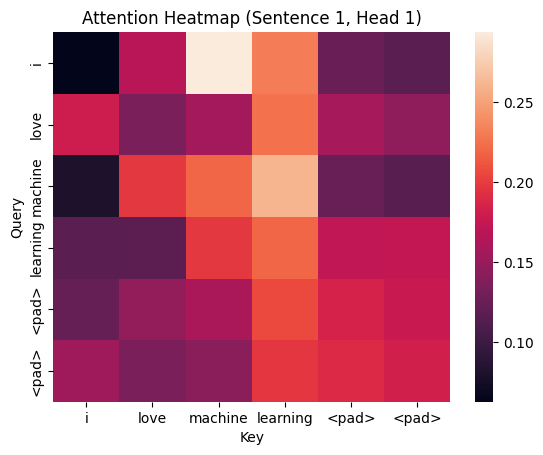

In [8]:
# ================================
# Q2)Mini Transformer Encoder (PyTorch)
# ================================

import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Dataset
# -------------------------------
sentences = [
    "i love machine learning",
    "transformers are powerful models",
    "deep learning is fun",
    "attention is all you need",
    "natural language processing is interesting",
    "i enjoy coding in python",
    "data science is exciting",
    "neural networks learn patterns",
    "this is a simple example",
    "we are building a transformer"
]

# -------------------------------
# 2. Tokenization
# -------------------------------
word2idx = {"<pad>": 0}
idx = 1

for sent in sentences:
    for word in sent.split():
        if word not in word2idx:
            word2idx[word] = idx
            idx += 1

idx2word = {v: k for k, v in word2idx.items()}

max_len = 6
tokenized = []

for sent in sentences:
    tokens = [word2idx[w] for w in sent.split()]
    tokens += [0] * (max_len - len(tokens))
    tokenized.append(tokens)

inputs = torch.tensor(tokenized)
print("\nInput Tokens:\n", inputs)

# -------------------------------
# 3. Embedding
# -------------------------------
d_model = 32
embedding = nn.Embedding(len(word2idx), d_model)
embedded = embedding(inputs)

# -------------------------------
# 4. Positional Encoding
# -------------------------------
def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = math.sin(pos / (10000 ** (i / d_model)))
            pe[pos, i+1] = math.cos(pos / (10000 ** (i / d_model)))
    return pe

pe = positional_encoding(max_len, d_model)
embedded = embedded + pe

# -------------------------------
# 5. Multi-Head Attention
# -------------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads=2):
        super().__init__()
        self.heads = heads
        self.d_k = d_model // heads

        self.qkv = nn.Linear(d_model, d_model * 3)
        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(batch_size, seq_len, self.heads, 3 * self.d_k)
        qkv = qkv.permute(0, 2, 1, 3)

        Q, K, V = torch.chunk(qkv, 3, dim=-1)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn = torch.softmax(scores, dim=-1)

        out = torch.matmul(attn, V)
        out = out.permute(0, 2, 1, 3).reshape(batch_size, seq_len, d_model)

        return self.fc(out), attn

# -------------------------------
# 6. Feed Forward
# -------------------------------
class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, d_model)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------------
# 7. Encoder Layer
# -------------------------------
class EncoderLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, heads=2)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn = self.mha(x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x, attn

# -------------------------------
# 8. Run Encoder
# -------------------------------
encoder = EncoderLayer(d_model)
output, attention = encoder(embedded)

print("\nFinal Contextual Embeddings Shape:\n", output.shape)
print("\nFinal Contextual Embeddings:\n", output)

# -------------------------------
# 9. Attention Heatmap
# -------------------------------
attn_matrix = attention[0][0].detach().numpy()

words = sentences[0].split()
words += ["<pad>"] * (max_len - len(words))

plt.figure()
sns.heatmap(attn_matrix, xticklabels=words, yticklabels=words)
plt.title("Attention Heatmap (Sentence 1, Head 1)")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()

In [9]:
# =========================================
# Q3)Scaled Dot-Product Attention (PyTorch)
# =========================================

import torch
import torch.nn.functional as F
import math

# -------------------------------
# 1. Attention Function
# -------------------------------
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)

    # Step 1: Compute raw scores
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # Step 2: Scale scores
    scaled_scores = scores / math.sqrt(d_k)

    # Step 3: Softmax
    attention_weights = F.softmax(scaled_scores, dim=-1)

    # Step 4: Weighted sum
    output = torch.matmul(attention_weights, V)

    return output, attention_weights, scores, scaled_scores

# -------------------------------
# 2. Generate Random Q, K, V
# -------------------------------
torch.manual_seed(42)

batch_size = 1
seq_len = 4
d_k = 8

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

# -------------------------------
# 3. Run Attention
# -------------------------------
output, attn_weights, raw_scores, scaled_scores = scaled_dot_product_attention(Q, K, V)

# -------------------------------
# 4. Print Results
# -------------------------------

print("\n=== RAW SCORES (QK^T) ===")
print(raw_scores)

print("\n=== SCALED SCORES (QK^T / sqrt(d_k)) ===")
print(scaled_scores)

print("\n=== ATTENTION WEIGHTS (Softmax) ===")
print(attn_weights)

print("\n=== OUTPUT VECTORS ===")
print(output)

# -------------------------------
# 5. Softmax Stability Check
# -------------------------------

# Softmax WITHOUT scaling
softmax_unscaled = F.softmax(raw_scores, dim=-1)

# Softmax WITH scaling
softmax_scaled = F.softmax(scaled_scores, dim=-1)

print("\n=== SOFTMAX WITHOUT SCALING ===")
print(softmax_unscaled)

print("\n=== SOFTMAX WITH SCALING ===")
print(softmax_scaled)

# Check if values are too sharp
print("\n=== MAX VALUES COMPARISON ===")
print("Max (Unscaled):", softmax_unscaled.max().item())
print("Max (Scaled):", softmax_scaled.max().item())


=== RAW SCORES (QK^T) ===
tensor([[[-5.8108, -3.6962, -4.3623, -8.6428],
         [-3.5381,  4.3192, -1.4130,  1.1963],
         [-3.0255, -1.0973, -1.4376,  1.4581],
         [-1.5793, -1.7662, -1.5380,  0.7021]]])

=== SCALED SCORES (QK^T / sqrt(d_k)) ===
tensor([[[-2.0544, -1.3068, -1.5423, -3.0557],
         [-1.2509,  1.5271, -0.4996,  0.4229],
         [-1.0697, -0.3879, -0.5083,  0.5155],
         [-0.5584, -0.6244, -0.5437,  0.2482]]])

=== ATTENTION WEIGHTS (Softmax) ===
tensor([[[0.1942, 0.4102, 0.3242, 0.0714],
         [0.0408, 0.6555, 0.0864, 0.2173],
         [0.1041, 0.2057, 0.1824, 0.5078],
         [0.1926, 0.1803, 0.1955, 0.4316]]])

=== OUTPUT VECTORS ===
tensor([[[ 0.2667,  0.2371, -0.0554,  0.1298,  0.3541, -0.1906, -0.6448,
          -0.0085],
         [ 0.1086,  0.2444, -0.2164,  0.3814,  0.0631, -0.5633, -1.1007,
          -0.3306],
         [ 0.4947, -0.1095, -0.5350,  0.3420, -0.6224, -0.4772,  0.3223,
           0.2335],
         [ 0.5705, -0.0146, -0.2775, 